# 03 — Modelo de Machine Learning

## Proyecto: HR Process Automation Scanner

El objetivo de este notebook es construir un modelo de Machine Learning capaz de predecir la prioridad de automatización de una unidad operativa de HR.

La variable objetivo será:

`automation_priority`

El problema se plantea como una clasificación multiclase, donde cada unidad operativa puede clasificarse como:

- Alta
- Media
- Baja

El modelo utilizará variables operativas como volumen de casos, tiempo de resolución, riesgo de SLA, escalaciones, complejidad, sistema HR, proceso HR, región y canal interno de contacto.

El objetivo final es construir un modelo que pueda integrarse posteriormente en una aplicación de Streamlit para recomendar prioridades de automatización de forma interactiva.

In [1]:
# Importar librerías y rutas:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
FINAL_DATA_PATH = DATA_PATH / "final"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Ruta data/final:", FINAL_DATA_PATH)
print("Ruta models:", MODELS_PATH)
print("Ruta reports:", REPORTS_PATH)

Ruta data/final: /Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/data/final
Ruta models: /Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/models
Ruta reports: /Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/reports


## 3.1 Carga del dataset limpio

En esta sección se carga el dataset final corregido generado en el notebook anterior.

Este archivo contiene la matriz de oportunidades de automatización con los canales internos HR ya adaptados al contexto de People Operations.

In [2]:
dataset_path = FINAL_DATA_PATH / "hr_process_automation_ranking_clean.csv"

df = pd.read_csv(dataset_path)

df.head()

,process_unit_id_v2,hr_process_name,hr_system_name,region,contact_channel,total_cases,avg_resolution_time_hours,avg_first_response_time_hours,sla_breach_rate,escalation_rate,avg_complexity_score,avg_satisfaction_score,avg_previous_cases,avg_employee_tenure_months,high_priority_rate,urgent_priority_rate,volume_score,resolution_time_score,first_response_score,sla_risk_score,escalation_score,complexity_score,previous_cases_score,high_priority_score,urgent_priority_score,automation_score,automation_priority,recommended_solution,estimated_savings_rate,estimated_hours_saved,estimated_manual_work_rate,estimated_manual_handling_time_hours,estimated_operational_hours_saved,ranking,hr_contact_channel
0,HR System Performance Issue | Payroll Payment Gateway | Europe | Social Media,HR System Performance Issue,Payroll Payment Gateway,Europe,Social Media,89,122.775281,40.720674,0.573034,0.460674,6.168539,2.921348,10.696629,31.359551,0.280899,0.280899,0.912281,0.507705,0.778446,0.635957,0.429538,0.738190,0.669811,0.604577,0.494353,66.45,Alta,Automatización parcial con alertas SLA,0.35,3824.45,0.18,22.10,688.42,1,Internal Collaboration Tool
1,Benefits Cancellation Request | Payroll System | Asia | Social Media,Benefits Cancellation Request,Payroll System,Asia,Social Media,84,121.301310,43.382857,0.571429,0.452381,6.392857,2.809524,10.488095,32.202381,0.309524,0.214286,0.824561,0.483172,0.920397,0.632284,0.411581,0.832642,0.627396,0.678526,0.328817,65.56,Alta,Automatización parcial con alertas SLA,0.35,3566.26,0.18,21.83,641.80,2,Internal Collaboration Tool
2,Benefits Reimbursement Request | Benefits Administration System | Europe | Phone,Benefits Reimbursement Request,Benefits Administration System,Europe,Phone,74,134.088243,43.979054,0.608108,0.567568,5.648649,2.702703,10.270270,30.297297,0.256757,0.229730,0.649123,0.695999,0.952186,0.716207,0.660988,0.519283,0.583091,0.542208,0.367196,65.23,Alta,Automatización parcial con alertas SLA,0.35,3472.89,0.18,24.14,625.23,3,Phone
3,Benefits Reimbursement Request | Employee Mobile App | Asia | Email,Benefits Reimbursement Request,Employee Mobile App,Asia,Email,76,140.531842,40.630526,0.526316,0.565789,6.065789,3.197368,10.355263,32.605263,0.236842,0.236842,0.684211,0.803246,0.773639,0.529065,0.657138,0.694925,0.600378,0.490760,0.384871,64.50,Alta,Automatización parcial con alertas SLA,0.35,3738.15,0.18,25.30,672.98,4,Email
4,Payroll Support Request | Payroll Payment Gateway | Asia | Chat,Payroll Support Request,Payroll Payment Gateway,Asia,Chat,82,121.986220,39.002317,0.512195,0.634146,5.951220,2.707317,11.243902,30.256098,0.243902,0.329268,0.789474,0.494572,0.686821,0.496757,0.805147,0.646684,0.781125,0.509000,0.614553,64.38,Alta,Chatbot o asistente virtual,0.35,3501.00,0.18,21.96,630.25,5,HR Chat / Virtual Assistant


In [3]:
# Revisar dimensiones y columnas:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.columns.tolist()

Filas: 3000
Columnas: 35


['process_unit_id_v2',
 'hr_process_name',
 'hr_system_name',
 'region',
 'contact_channel',
 'total_cases',
 'avg_resolution_time_hours',
 'avg_first_response_time_hours',
 'sla_breach_rate',
 'escalation_rate',
 'avg_complexity_score',
 'avg_satisfaction_score',
 'avg_previous_cases',
 'avg_employee_tenure_months',
 'high_priority_rate',
 'urgent_priority_rate',
 'volume_score',
 'resolution_time_score',
 'first_response_score',
 'sla_risk_score',
 'escalation_score',
 'complexity_score',
 'previous_cases_score',
 'high_priority_score',
 'urgent_priority_score',
 'automation_score',
 'automation_priority',
 'recommended_solution',
 'estimated_savings_rate',
 'estimated_hours_saved',
 'estimated_manual_work_rate',
 'estimated_manual_handling_time_hours',
 'estimated_operational_hours_saved',
 'ranking',
 'hr_contact_channel']

In [4]:
# Revisar variable objetivo:
df["automation_priority"].value_counts()

automation_priority
Media    1497
Alta      753
Baja      750
Name: count, dtype: int64

## 3.2 Definición del problema de Machine Learning

El problema se define como una clasificación multiclase.

La variable objetivo es `automation_priority`, que clasifica cada unidad operativa según su prioridad de automatización:

- Alta
- Media
- Baja

El modelo aprenderá a predecir esta prioridad usando variables operativas, categóricas y de rendimiento.

In [5]:
# Definir variables predictoras y target:
target = "automation_priority"

features = [
    "hr_process_name",
    "hr_system_name",
    "hr_contact_channel",
    "region",
    "total_cases",
    "avg_resolution_time_hours",
    "avg_first_response_time_hours",
    "sla_breach_rate",
    "escalation_rate",
    "avg_complexity_score",
    "avg_satisfaction_score",
    "avg_previous_cases",
    "avg_employee_tenure_months",
    "high_priority_rate",
    "urgent_priority_rate"
]

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 15)
y shape: (3000,)


In [6]:
# Revisar tipos de variables:
X.dtypes

hr_process_name                   object
hr_system_name                    object
hr_contact_channel                object
region                            object
total_cases                        int64
avg_resolution_time_hours        float64
avg_first_response_time_hours    float64
sla_breach_rate                  float64
escalation_rate                  float64
avg_complexity_score             float64
avg_satisfaction_score           float64
avg_previous_cases               float64
avg_employee_tenure_months       float64
high_priority_rate               float64
urgent_priority_rate             float64
dtype: object

In [7]:
# Separar variables numéricas y categóricas:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['hr_process_name', 'hr_system_name', 'hr_contact_channel', 'region']

Variables numéricas:
['total_cases', 'avg_resolution_time_hours', 'avg_first_response_time_hours', 'sla_breach_rate', 'escalation_rate', 'avg_complexity_score', 'avg_satisfaction_score', 'avg_previous_cases', 'avg_employee_tenure_months', 'high_priority_rate', 'urgent_priority_rate']


## 3.3 División en entrenamiento y prueba

Se divide el dataset en dos conjuntos:

- entrenamiento: para que el modelo aprenda;
- prueba: para evaluar el rendimiento sobre datos no vistos.

Se utiliza estratificación para mantener la proporción de clases Alta, Media y Baja en ambos conjuntos.

In [8]:
# Train/test split:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2400, 15)
X_test: (600, 15)
y_train: (2400,)
y_test: (600,)


In [9]:
# Ver distribución de clases en train y test:
train_distribution = y_train.value_counts(normalize=True).round(3)
test_distribution = y_test.value_counts(normalize=True).round(3)

class_distribution = pd.DataFrame({
    "train_distribution": train_distribution,
    "test_distribution": test_distribution
})

class_distribution

,train_distribution,test_distribution
automation_priority,,
Media,0.499,0.498
Alta,0.251,0.252
Baja,0.250,0.250


## 3.4 Preprocesamiento

El dataset contiene variables numéricas y categóricas.

Para preparar los datos:

- las variables numéricas serán escaladas con `StandardScaler`;
- las variables categóricas serán transformadas con `OneHotEncoder`.

Este preprocesamiento se integrará dentro de un pipeline para evitar fugas de datos y mantener un flujo reproducible.

In [10]:
# Crear preprocesador:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['total_cases', 'avg_resolution_time_hours',
                                  'avg_first_response_time_hours',
                                  'sla_breach_rate', 'escalation_rate',
                                  'avg_complexity_score',
                                  'avg_satisfaction_score',
                                  'avg_previous_cases',
                                  'avg_employee_tenure_months',
                                  'high_priority_rate',
                                  'urgent_priority_rate']),
                                ('categorical',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['hr_process_name', 'hr_system_name',
                                  'hr_contact_channel', 'region'])])

## 3.5 Entrenamiento de modelos base

Se probarán varios modelos de clasificación para comparar su rendimiento:

- Regresión logística;
- Árbol de decisión;
- Random Forest;
- Gradient Boosting.

La métrica principal será `f1_macro`, porque permite evaluar el rendimiento promedio entre las tres clases sin favorecer únicamente la clase mayoritaria.

In [11]:
# Definir modelos a evaluar:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [12]:
# Entrenar y evaluar modelos:
model_results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    }
    
    model_results.append(results)
    trained_models[model_name] = pipeline

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values("f1_macro", ascending=False)
)

model_results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.968333,0.968112,0.968925,0.968472
3,Gradient Boosting,0.816667,0.853220,0.782633,0.807631
2,Random Forest,0.790000,0.881360,0.727469,0.768652
1,Decision Tree,0.661667,0.660925,0.661486,0.660616


## 3.6 Selección del modelo ganador

Después de entrenar varios modelos base, el mejor rendimiento lo obtuvo la Regresión Logística.

Aunque es un modelo simple, en este caso funciona muy bien porque la variable objetivo automation_priority fue construida a partir de una lógica de negocio estructurada y reglas de negocio basadas en variables operativas. Por tanto, el modelo está aprendiendo a replicar una lógica de priorización definida previamente (replica la relación entre las variables operativas y la prioridad de automatización).

Lo primero fue construír una lógica de negocio basada en score. Después entrenar un modelo para aprender esa lógica y permitir que futuras unidades operativas puedan clasificarse automáticamente.

Esto dio como resultado un modelo de decisión asistida basado en reglas de negocio y Machine Learning.

Esto es útil porque permite clasificar nuevas unidades operativas de HR de forma automática y consistente.

In [13]:
# Seleccionar modelo ganador:
best_model_name = model_results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Mejor modelo:", best_model_name)

Mejor modelo: Logistic Regression


In [14]:
# Predicciones del modelo ganador:
y_pred = best_model.predict(X_test)

y_pred[:10]

array(['Media', 'Media', 'Alta', 'Media', 'Alta', 'Media', 'Media',
       'Media', 'Baja', 'Media'], dtype=object)

In [15]:
# Classification report del modelo ganador:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Alta       0.95      0.97      0.96       151
        Baja       0.99      0.97      0.98       150
       Media       0.97      0.97      0.97       299

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



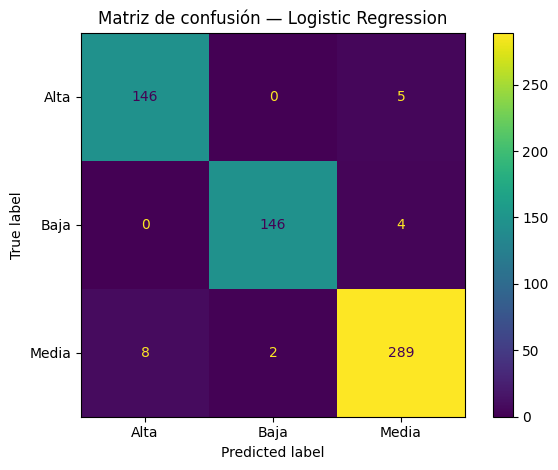

In [16]:
# Matriz de confusión del modelo ganador:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()
plt.title(f"Matriz de confusión — {best_model_name}")
plt.tight_layout()
plt.show()

In [17]:
# Métricas finales del modelo ganador:
final_model_metrics = pd.DataFrame({
    "métrica": [
        "Modelo ganador",
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "valor": [
        best_model_name,
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, average="macro"), 4),
        round(recall_score(y_test, y_pred, average="macro"), 4),
        round(f1_score(y_test, y_pred, average="macro"), 4)
    ]
})

final_model_metrics

,métrica,valor
0,Modelo ganador,Logistic Regression
1,Accuracy,0.9683
2,Precision macro,0.9681
3,Recall macro,0.9689
4,F1 macro,0.9685


### Interpretación del modelo ganador

La Regresión Logística obtuvo el mejor rendimiento entre los modelos evaluados.

El resultado indica que el modelo es capaz de clasificar correctamente la prioridad de automatización de la mayoría de las unidades operativas.

Este rendimiento alto se explica porque la variable objetivo `automation_priority` fue construida a partir de una lógica de negocio basada en variables operativas como volumen, SLA, escalaciones, complejidad, tiempos y prioridad.

Por tanto, el modelo no debe interpretarse como una predicción causal, sino como un sistema de clasificación automatizada que aprende una lógica de priorización previamente definida.

En términos de negocio, esto permite aplicar la misma lógica de priorización a nuevas unidades operativas sin tener que recalcular manualmente todo el sistema de scoring.

El modelo no predice una verdad externa independiente, sino que aprende una lógica de priorización construida a partir de reglas de negocio. Su valor está en automatizar esa clasificación para nuevas unidades operativas.

## 3.7 Interpretación de variables del modelo

Después de seleccionar el modelo ganador, se analizarán las variables que más influyen en la clasificación de prioridad de automatización.

Como el modelo ganador es una Regresión Logística, se pueden revisar sus coeficientes para entender qué variables empujan la predicción hacia una clase u otra.

Este análisis ayuda a conectar el modelo con la lógica de negocio del proyecto.

In [18]:
# Obtener nombres de variables después del preprocesamiento
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

feature_names[:20]

array(['numeric__total_cases', 'numeric__avg_resolution_time_hours',
       'numeric__avg_first_response_time_hours',
       'numeric__sla_breach_rate', 'numeric__escalation_rate',
       'numeric__avg_complexity_score', 'numeric__avg_satisfaction_score',
       'numeric__avg_previous_cases',
       'numeric__avg_employee_tenure_months',
       'numeric__high_priority_rate', 'numeric__urgent_priority_rate',
       'categorical__hr_process_name_Benefits Cancellation Request',
       'categorical__hr_process_name_Benefits Reimbursement Request',
       'categorical__hr_process_name_Compliance & Access Security Review',
       'categorical__hr_process_name_Employee Data Update',
       'categorical__hr_process_name_HR Platform Bug Report',
       'categorical__hr_process_name_HR System Enhancement Request',
       'categorical__hr_process_name_HR System Performance Issue',
       'categorical__hr_process_name_HRIS Access Suspension',
       'categorical__hr_process_name_HRIS Login Issue']

In [19]:
# Extraer el modelo interno de regresión logística
logistic_model = best_model.named_steps["model"]

# Crear DataFrame de coeficientes por clase
coefficients_df = pd.DataFrame(
    logistic_model.coef_,
    columns=feature_names,
    index=logistic_model.classes_
)

coefficients_df.head()

,numeric__total_cases,numeric__avg_resolution_time_hours,numeric__avg_first_response_time_hours,numeric__sla_breach_rate,numeric__escalation_rate,numeric__avg_complexity_score,numeric__avg_satisfaction_score,numeric__avg_previous_cases,numeric__avg_employee_tenure_months,numeric__high_priority_rate,numeric__urgent_priority_rate,categorical__hr_process_name_Benefits Cancellation Request,categorical__hr_process_name_Benefits Reimbursement Request,categorical__hr_process_name_Compliance & Access Security Review,categorical__hr_process_name_Employee Data Update,categorical__hr_process_name_HR Platform Bug Report,categorical__hr_process_name_HR System Enhancement Request,categorical__hr_process_name_HR System Performance Issue,categorical__hr_process_name_HRIS Access Suspension,categorical__hr_process_name_HRIS Login Issue,categorical__hr_process_name_Payroll Support Request,categorical__hr_system_name_Benefits Administration System,categorical__hr_system_name_Benefits Portal,categorical__hr_system_name_Employee Mobile App,categorical__hr_system_name_Employee Self-Service Portal,categorical__hr_system_name_HR Case Management Platform,categorical__hr_system_name_HR Document Management System,categorical__hr_system_name_HRIS Integration API,categorical__hr_system_name_Payroll Payment Gateway,categorical__hr_system_name_Payroll System,categorical__hr_system_name_People Analytics Dashboard,categorical__hr_contact_channel_Email,categorical__hr_contact_channel_Employee Self-Service Portal,categorical__hr_contact_channel_HR Chat / Virtual Assistant,categorical__hr_contact_channel_Internal Collaboration Tool,categorical__hr_contact_channel_Phone,categorical__region_Africa,categorical__region_Asia,categorical__region_Australia,categorical__region_Europe,categorical__region_North America,categorical__region_South America
Alta,5.978374,4.500567,2.924532,4.428985,2.805737,3.202258,0.041098,1.558599,0.028749,2.156655,2.181370,-0.02901,0.143270,0.089777,0.034022,0.003539,-0.231233,-0.146826,0.261577,0.040718,-0.188674,-0.162779,0.042948,-0.221294,-0.092693,0.025956,0.210913,-0.202546,0.049732,0.434218,-0.107295,0.050314,0.144964,0.016136,-0.215578,-0.018676,0.001225,-0.394624,0.175741,0.184935,0.083102,-0.073218
Baja,-5.892302,-4.453481,-2.873499,-4.339804,-2.763133,-3.172514,-0.045991,-1.604869,0.036829,-2.090557,-2.099623,-0.09058,-0.104525,-0.027674,0.016401,-0.061526,0.002278,0.127027,-0.010776,0.107603,0.061047,0.236174,-0.012594,0.142831,-0.007523,0.005951,-0.120682,-0.028839,0.004420,-0.299201,0.098740,-0.028190,-0.202803,0.161110,0.167963,-0.078804,0.098237,0.358768,-0.041391,-0.134395,-0.143841,-0.118101
Media,-0.086071,-0.047086,-0.051033,-0.089181,-0.042604,-0.029743,0.004893,0.046269,-0.065578,-0.066098,-0.081747,0.11959,-0.038745,-0.062103,-0.050423,0.057987,0.228955,0.019799,-0.250801,-0.148321,0.127627,-0.073395,-0.030355,0.078463,0.100216,-0.031907,-0.090231,0.231386,-0.054152,-0.135016,0.008556,-0.022124,0.057839,-0.177247,0.047615,0.097480,-0.099461,0.035857,-0.134350,-0.050539,0.060739,0.191319


In [20]:
# Mostrar variables con mayor peso positivo por cada clase
top_features_by_class = {}

for class_name in coefficients_df.index:
    top_features = (
        coefficients_df
        .loc[class_name]
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    
    top_features.columns = ["feature", "coefficient"]
    top_features_by_class[class_name] = top_features
    
    print("\n" + "=" * 80)
    print(f"CLASE: {class_name}")
    print("=" * 80)
    display(top_features)


CLASE: Alta


,feature,coefficient
0,numeric__total_cases,5.978374
1,numeric__avg_resolution_time_hours,4.500567
2,numeric__sla_breach_rate,4.428985
3,numeric__avg_complexity_score,3.202258
4,numeric__avg_first_response_time_hours,2.924532
5,numeric__escalation_rate,2.805737
6,numeric__urgent_priority_rate,2.181370
7,numeric__high_priority_rate,2.156655
8,numeric__avg_previous_cases,1.558599
9,categorical__hr_system_name_Payroll System,0.434218



CLASE: Baja


,feature,coefficient
0,categorical__region_Asia,0.358768
1,categorical__hr_system_name_Benefits Administration System,0.236174
2,categorical__hr_contact_channel_Internal Collaboration Tool,0.167963
3,categorical__hr_contact_channel_HR Chat / Virtual Assistant,0.161110
4,categorical__hr_system_name_Employee Mobile App,0.142831
5,categorical__hr_process_name_HR System Performance Issue,0.127027
6,categorical__hr_process_name_HRIS Login Issue,0.107603
7,categorical__hr_system_name_People Analytics Dashboard,0.098740
8,categorical__region_Africa,0.098237
9,categorical__hr_process_name_Payroll Support Request,0.061047



CLASE: Media


,feature,coefficient
0,categorical__hr_system_name_HRIS Integration API,0.231386
1,categorical__hr_process_name_HR System Enhancement Request,0.228955
2,categorical__region_South America,0.191319
3,categorical__hr_process_name_Payroll Support Request,0.127627
4,categorical__hr_process_name_Benefits Cancellation Request,0.119590
5,categorical__hr_system_name_Employee Self-Service Portal,0.100216
6,categorical__hr_contact_channel_Phone,0.097480
7,categorical__hr_system_name_Employee Mobile App,0.078463
8,categorical__region_North America,0.060739
9,categorical__hr_process_name_HR Platform Bug Report,0.057987


In [21]:
# Variables más influyentes para prioridad Alta:
top_features_alta = (
    coefficients_df
    .loc["Alta"]
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_features_alta.columns = ["feature", "coefficient"]

top_features_alta

,feature,coefficient
0,numeric__total_cases,5.978374
1,numeric__avg_resolution_time_hours,4.500567
2,numeric__sla_breach_rate,4.428985
3,numeric__avg_complexity_score,3.202258
4,numeric__avg_first_response_time_hours,2.924532
5,numeric__escalation_rate,2.805737
6,numeric__urgent_priority_rate,2.181370
7,numeric__high_priority_rate,2.156655
8,numeric__avg_previous_cases,1.558599
9,categorical__hr_system_name_Payroll System,0.434218


### Interpretación de las variables más influyentes para prioridad alta

Las variables que más impulsan la predicción de prioridad alta están relacionadas principalmente con volumen, tiempos, riesgo operativo y complejidad.

El modelo asigna mayor peso a variables como `total_cases`, `avg_resolution_time_hours`, `sla_breach_rate`, `avg_complexity_score`, `avg_first_response_time_hours` y `escalation_rate`.

Esto es coherente con la lógica de negocio del proyecto: una unidad operativa debe priorizarse para automatización cuando combina alto volumen, tiempos elevados, incumplimiento de SLA, escalaciones frecuentes y mayor complejidad.

También aparecen algunas variables categóricas relacionadas con sistemas, procesos, regiones y canales internos. Sin embargo, las variables numéricas son las que tienen mayor peso, lo que indica que el modelo está priorizando principalmente señales operativas y no solo etiquetas descriptivas.

En términos de negocio, el modelo confirma que las mejores oportunidades de automatización no dependen únicamente del tipo de proceso HR, sino del nivel de fricción operativa que presenta cada unidad.

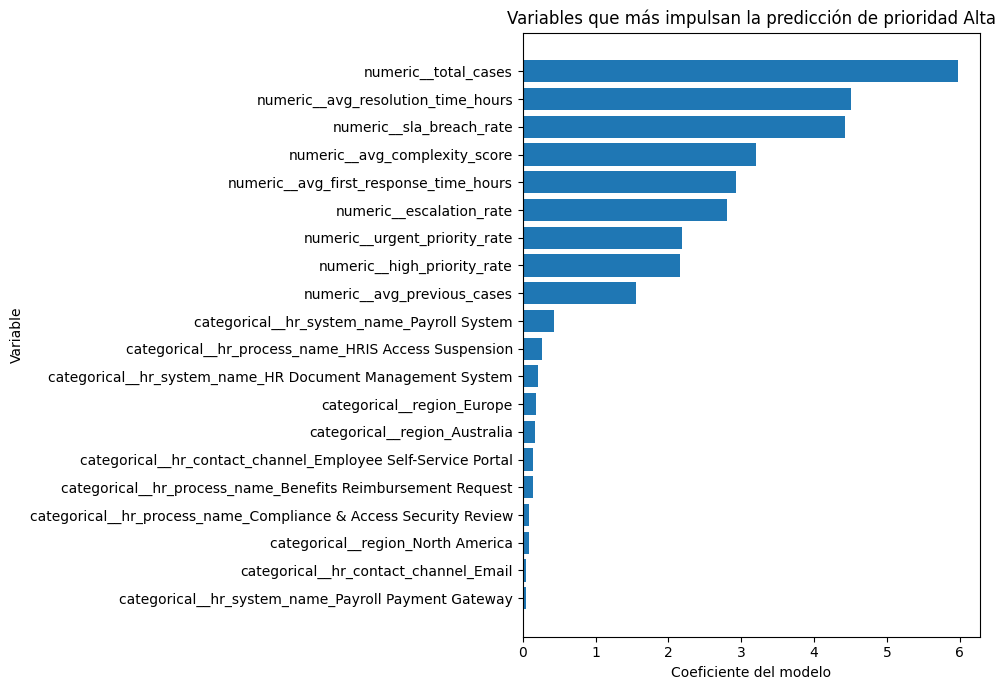

In [22]:
# Gráfico de variables para prioridad Alta
top_features_alta_plot = top_features_alta.sort_values("coefficient", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features_alta_plot["feature"],
    top_features_alta_plot["coefficient"]
)

plt.title("Variables que más impulsan la predicción de prioridad Alta")
plt.xlabel("Coeficiente del modelo")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Interpretación de variables

El análisis de coeficientes permite identificar qué variables aumentan la probabilidad de que una unidad operativa sea clasificada con prioridad alta, media o baja.

En este proyecto, las variables más importantes deberían estar relacionadas con factores como:

- volumen de casos;
- incumplimiento de SLA;
- escalaciones;
- tiempos de resolución;
- complejidad;
- prioridad alta o urgente;
- tipo de proceso;
- sistema HR;
- canal interno.

Esto es coherente con la lógica de negocio utilizada para construir el Automation Opportunity Score.

### Interpretación de las variables más influyentes para prioridad alta

Las variables que más impulsan la predicción de prioridad alta están relacionadas principalmente con volumen, tiempos, riesgo operativo y complejidad.

El modelo asigna mayor peso a variables como `total_cases`, `avg_resolution_time_hours`, `sla_breach_rate`, `avg_complexity_score`, `avg_first_response_time_hours` y `escalation_rate`.

Esto es coherente con la lógica de negocio del proyecto: una unidad operativa debe priorizarse para automatización cuando combina alto volumen, tiempos elevados, incumplimiento de SLA, escalaciones frecuentes y mayor complejidad.

También aparecen algunas variables categóricas relacionadas con sistemas, procesos, regiones y canales internos. Sin embargo, las variables numéricas son las que tienen mayor peso, lo que indica que el modelo está priorizando principalmente señales operativas y no solo etiquetas descriptivas.

En términos de negocio, el modelo confirma que las mejores oportunidades de automatización no dependen únicamente del tipo de proceso HR, sino del nivel de fricción operativa que presenta cada unidad.

## 3.8 Exportación del modelo y resultados

En esta sección se guardan los principales artefactos del modelo de Machine Learning.

Estos archivos serán utilizados posteriormente para documentación, presentación ejecutiva y construcción de la aplicación en Streamlit.

## Guardar modelo

In [23]:
import joblib

In [24]:
model_path = MODELS_PATH / "automation_priority_model.pkl"

joblib.dump(best_model, model_path)

print("Modelo guardado correctamente en:")
print(model_path)

Modelo guardado correctamente en:
/Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/models/automation_priority_model.pkl


In [25]:
# Guardar métricas finales en CSV:
model_results_df.to_csv(
    REPORTS_PATH / "model_comparison_results.csv",
    index=False
)

final_model_metrics.to_csv(
    REPORTS_PATH / "final_model_metrics.csv",
    index=False
)

top_features_alta.to_csv(
    REPORTS_PATH / "top_features_priority_alta.csv",
    index=False
)

print("Resultados del modelo guardados correctamente en reports.")


Resultados del modelo guardados correctamente en reports.


In [26]:
# Verificar archivos guardados
print("Archivos en models:")
for file_path in MODELS_PATH.glob("*"):
    print(file_path.name)

print("\nArchivos en reports:")
for file_path in REPORTS_PATH.glob("*.csv"):
    print(file_path.name)

Archivos en models:
automation_priority_model.pkl

Archivos en reports:
solution_summary.csv
region_summary.csv
top_features_priority_alta.csv
final_model_metrics.csv
model_comparison_results.csv
system_score_summary.csv
channel_summary.csv
final_priority_matrix.csv


## 3.9 Conclusiones del modelo de Machine Learning

En este notebook se construyó un modelo de Machine Learning para predecir la prioridad de automatización de una unidad operativa de HR.

El problema fue definido como una clasificación multiclase, donde la variable objetivo fue `automation_priority`, con tres posibles clases:

- Alta;
- Media;
- Baja.

Se utilizaron variables operativas, categóricas y de rendimiento, incluyendo proceso HR, sistema HR, región, canal interno, volumen de casos, tiempos de resolución, incumplimiento de SLA, escalaciones, complejidad, satisfacción, recurrencia y prioridad de casos.

Se probaron varios modelos de clasificación:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- Gradient Boosting.

El modelo con mejor rendimiento fue Logistic Regression, con un F1 macro aproximado de 0.9685.

Este resultado indica que el modelo fue capaz de aprender con alta precisión la lógica de priorización construida previamente mediante reglas de negocio.

Es importante aclarar que el modelo no predice una verdad externa independiente, sino que aprende una lógica de decisión diseñada para clasificar oportunidades de automatización de forma consistente.

Desde una perspectiva de negocio, el modelo permite automatizar la clasificación de nuevas unidades operativas y mantener un criterio homogéneo para decidir qué procesos deberían priorizarse.

El análisis de variables mostró que las señales más influyentes para predecir prioridad alta fueron:

- volumen de casos;
- tiempo medio de resolución;
- tasa de incumplimiento de SLA;
- complejidad media;
- tiempo de primera respuesta;
- tasa de escalación;
- proporción de casos urgentes;
- proporción de casos de prioridad alta;
- recurrencia de casos.

Esto confirma que el modelo está alineado con la lógica operativa del proyecto: las mejores oportunidades de automatización son aquellas que combinan volumen, fricción, riesgo, complejidad y criticidad.

Finalmente, se guardaron los principales artefactos del modelo:

- modelo entrenado;
- comparación de modelos;
- métricas finales;
- variables más influyentes para prioridad alta.

Estos archivos serán utilizados en la siguiente fase del proyecto: construcción de la aplicación interactiva en Streamlit.